# 威斯康辛州乳腺癌数据集分类实验

---

**本实验将对威斯康辛州乳腺癌数据集（Breast Cancer Wisconsin Diagnostic）进行二分类建模，判断肿瘤为良性（Benign）还是恶性（Malignant）。**

## 一、实验背景

乳腺癌是全球女性最常见的恶性肿瘤之一。基于细胞核显微图像的测量数据进行自动诊断，能够为医生提供有价值的辅助参考。

威斯康辛州乳腺癌数据集包含从乳腺肿块细针抽吸（FNA）图像中计算出的特征，共569个样本、30个实数特征。

**实验选用分类方法：**
1. **Logistic Regression（逻辑回归）** — 线性基线模型
2. **Gaussian Naive Bayes（高斯朴素贝叶斯）** — 概率生成模型
3. **XGBoost（极端梯度提升）** — 梯度提升集成模型

**评价指标：**
- Accuracy（准确率）
- Precision（精确率）
- Recall（召回率）
- F1-Score
- Training Time（训练时间）
- ROC-AUC

> 对于乳腺癌诊断场景，Recall 是一项关键指标——漏诊恶性将导致严重后果。

## 二、数据集介绍与处理

### 2.1 导入所需库

In [1]:
import numpy as np
import pandas as pd
import os
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# 中文和负号设置
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

np.random.seed(42)
print("[OK] 全部库已导入")

[OK] 全部库已导入


### 2.2 数据集获取与构建

我们从Kaggle下载该数据集并读取到DataFrame中。使用`kagglehub`库可免去配置API密钥的步骤。

> 先检查本地是否已有数据文件，避免重复下载。

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data", output_dir='./data')

print("Path to dataset files:", path)

Path to dataset files: ./data


In [4]:
## List all files in the data directory

for root, dirs, files in os.walk('./data'):
    print(root)
    for file in files:
        print("   ", file)

./data
    data.csv
./data\.complete
./data\.complete\datasets
./data\.complete\datasets\uciml
./data\.complete\datasets\uciml\breast-cancer-wisconsin-data
./data\.complete\datasets\uciml\breast-cancer-wisconsin-data\2
    bundle.complete


In [5]:
import os
df = pd.read_csv(os.path.join('./data', 'data.csv'))
print(f"数据集形状: {df.shape}")
print(f"列数: {len(df.columns)}")
print(f"缺失值总数: {df.isnull().sum().sum()}")

数据集形状: (569, 33)
列数: 33
缺失值总数: 569


先列出几个样本看看，了解数据集的结构。

In [6]:
## Display the first 5 rows of the dataframe with columns as rows
df.head(5).T

,0,1,2,3,4
id,842302,842517,84300903,84348301,84358402
diagnosis,M,M,M,M,M
radius_mean,17.99,20.57,19.69,11.42,20.29
texture_mean,10.38,17.77,21.25,20.38,14.34
perimeter_mean,122.8,132.9,130.0,77.58,135.1
area_mean,1001.0,1326.0,1203.0,386.1,1297.0
smoothness_mean,0.1184,0.08474,0.1096,0.1425,0.1003
compactness_mean,0.2776,0.07864,0.1599,0.2839,0.1328
concavity_mean,0.3001,0.0869,0.1974,0.2414,0.198
concave points_mean,0.1471,0.07017,0.1279,0.1052,0.1043


从结果观察到（注意这里为了便于观察使用了转置）：
- `id` 列为编号，对分类没有意义
- `diagnosis` 为目标变量：B（良性）和 M（恶性）
- 其余30列为细胞核的实数测量特征（radius_mean, texture_mean, ...）
- `Unnamed: 32` 全部为NaN，后续需要删除

### 2.3 数据预处理

删除无用列，将标签编码为数值。

In [7]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print(f"清洗后形状: {df.shape}")
print(f"标签分布:\n{df['diagnosis'].value_counts()}")

清洗后形状: (569, 31)
标签分布:
diagnosis
0    357
1    212
Name: count, dtype: int64


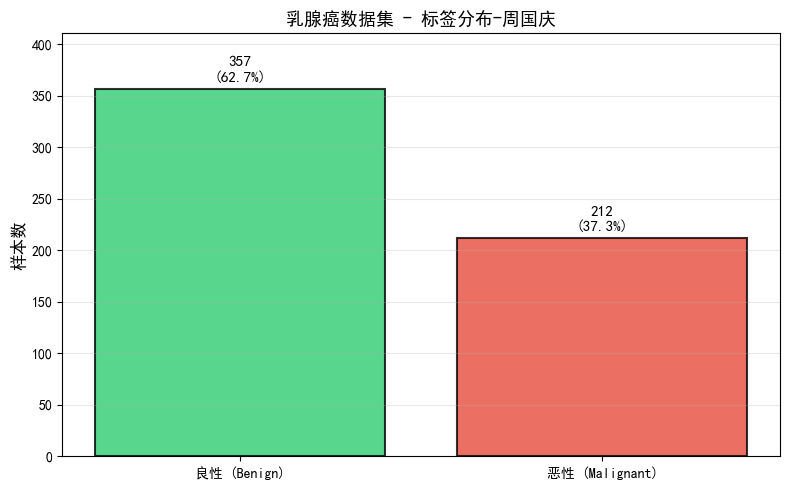

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
diagnosis_counts = df['diagnosis'].value_counts().sort_index()
labels = ['良性 (Benign)', '恶性 (Malignant)']
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(labels, diagnosis_counts.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# 添加数值标签和百分比
for bar, count in zip(bars, diagnosis_counts.values):
    height = bar.get_height()
    percentage = (count / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2, height + 5,
            f'{int(count)}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('样本数', fontsize=12)
ax.set_title('乳腺癌数据集 - 标签分布-周国庆', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(diagnosis_counts.values) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**标签分布分析：**
- 良性（0）：357 例（62.7%）
- 恶性（1）：212 例（37.3%）

类别存在一定不平衡，但比例约为 1.68:1，尚在可接受范围。后续建模时可以注意这一特点。

### 2.4 数据集探索（EDA）

#### 2.4.1 特征描述性统计

查看特征的基本统计量，初步了解数据的取值范围和分布。

In [9]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.373,0.484,0.000,0.000,0.000,1.000,1.000
radius_mean,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave points_mean,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304


可以看到各个特征的量纲差异较大（如 radius_mean 范围在 6~29, texture_mean 在 9~39, area_mean 在 144~2501）。
因此后续需要进行标准化处理。

#### 2.4.2 类别分布比较

先用箱线图看各个特征在良性/恶性之间的差异。这里将30个特征分为三组：Mean、SE、Worst，分别绘制。

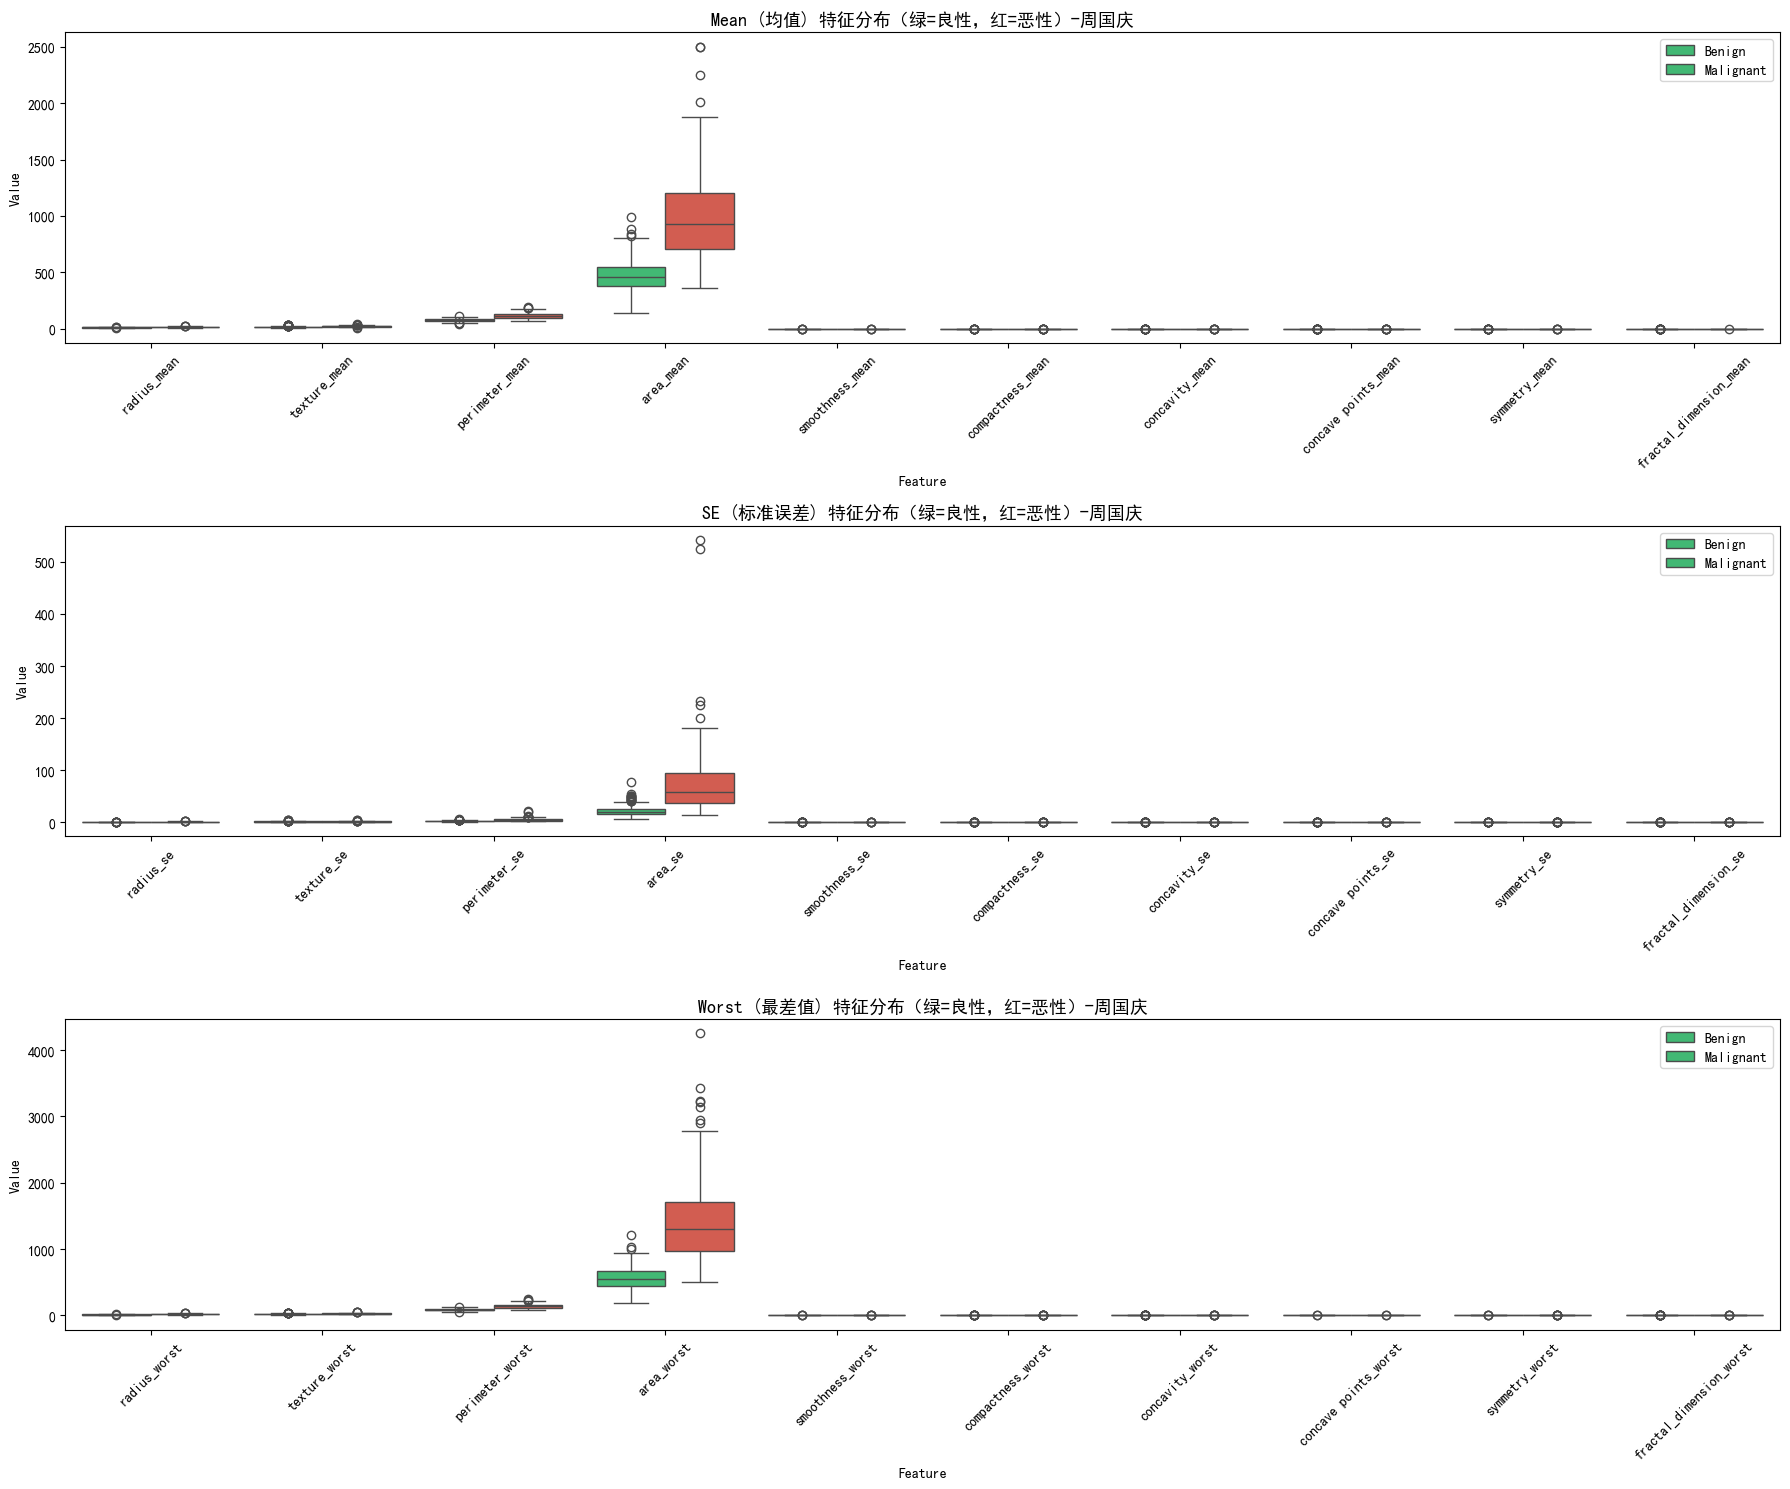

In [10]:
feature_groups = {
    'Mean (均值)': [c for c in df.columns if c.endswith('_mean')],
    'SE (标准误差)': [c for c in df.columns if c.endswith('_se')],
    'Worst (最差值)': [c for c in df.columns if c.endswith('_worst')]
}

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

for idx, (group_name, features) in enumerate(feature_groups.items()):
    df_melt = df.melt(id_vars=['diagnosis'], value_vars=features,
                      var_name='Feature', value_name='Value')
    sns.boxplot(data=df_melt, x='Feature', y='Value', hue='diagnosis',
                palette={0: '#2ecc71', 1: '#e74c3c'}, ax=axes[idx])
    axes[idx].set_title(f'{group_name} 特征分布（绿=良性，红=恶性）-周国庆', fontsize=13)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(['Benign', 'Malignant'])

plt.tight_layout()
plt.show()

**箱线图分析：**
- 在 Mean 和 Worst 两组特征中，恶性肿瘤的特征值普遍高于良性，且差异明显
- Worst 组（各特征的最差值）的区分度最好，两类之间的重叠最少
- SE 组（标准误差）的差异相对较小
- 部分特征存在离群点，但考虑到这是医学数据，可能是真实的极端病例，暂不删除

#### 2.4.3 相关性分析

计算特征之间的相关性，判断是否存在多重共线性，以及哪些特征与诊断结果最相关。

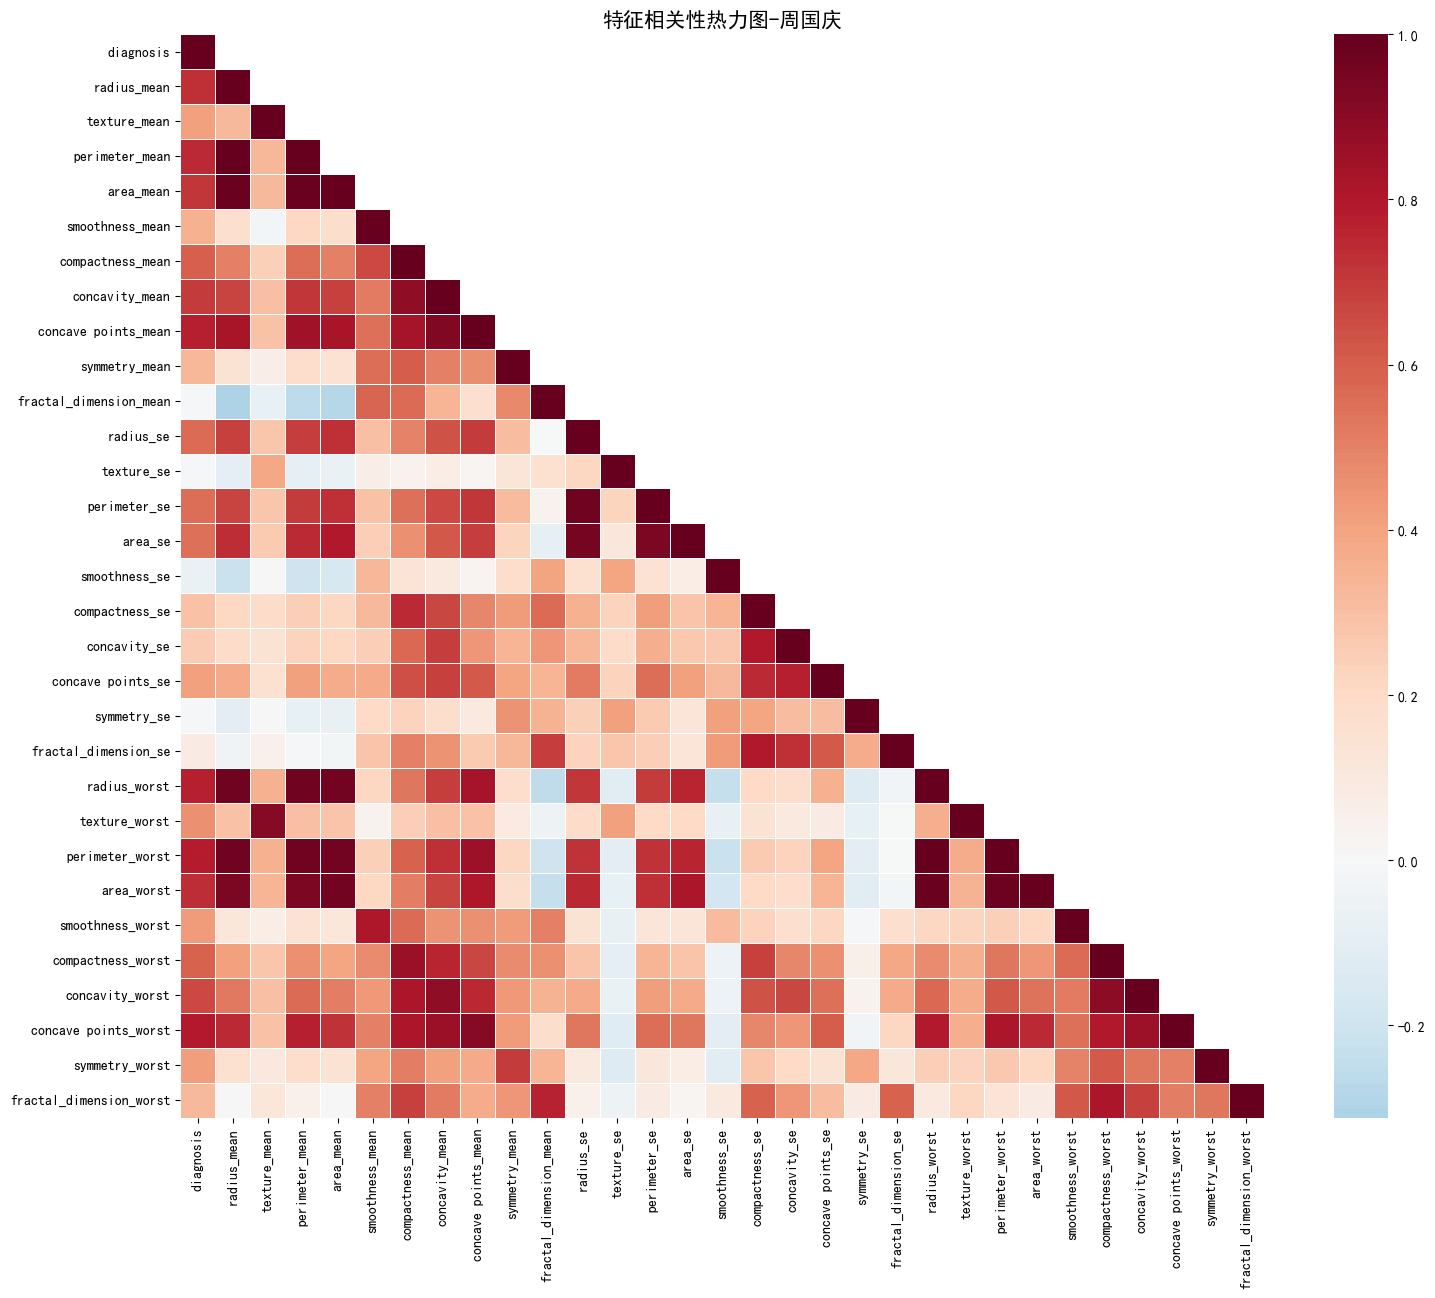

In [11]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('特征相关性热力图-周国庆', fontsize=15)
plt.tight_layout()
plt.show()

相关性热图显示大量特征之间存在高度相关性（>0.8），特别在 radius、perimeter、area 三类测量之间。

接下来查看与 diagnosis 最相关的前10个特征。

In [12]:
top_corr = corr_matrix['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False).head(10)
print("与诊断结果最相关的10个特征:")
print(top_corr)

与诊断结果最相关的10个特征:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


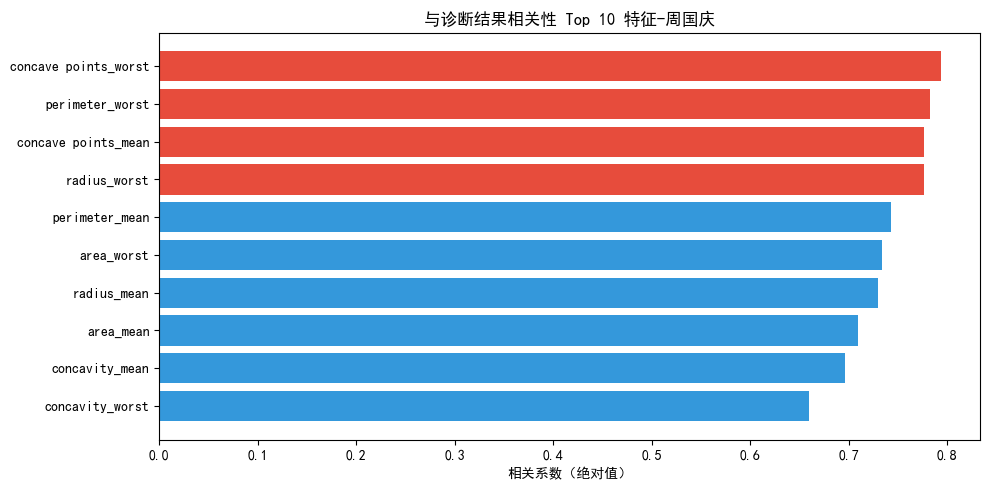

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 0.75 else '#3498db' for v in top_corr.values]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
ax.set_xlabel('相关系数（绝对值）')
ax.set_title('与诊断结果相关性 Top 10 特征-周国庆')
plt.tight_layout()
plt.show()

**相关性分析总结：**
- `concave points_worst`、`perimeter_worst`、`radius_worst` 等与诊断结果相关性最高（均接近0.8）
- 这些高度相关特征在后续模型中将贡献较大的权重
- 特征间的高相关性提示可以使用PCA降维来简化模型

#### 2.4.4 PCA降维可视化

将30维特征降至2维，在二维平面上观察两类样本的分布情况，判断数据的线性可分性。

In [14]:
X_all = df.drop(columns=['diagnosis']).values
y_all = df['diagnosis'].values

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

print(f"PC1 解释方差: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 解释方差: {pca.explained_variance_ratio_[1]:.2%}")
print(f"前2个主成分累计: {pca.explained_variance_ratio_.sum():.2%}")

PC1 解释方差: 44.27%
PC2 解释方差: 18.97%
前2个主成分累计: 63.24%


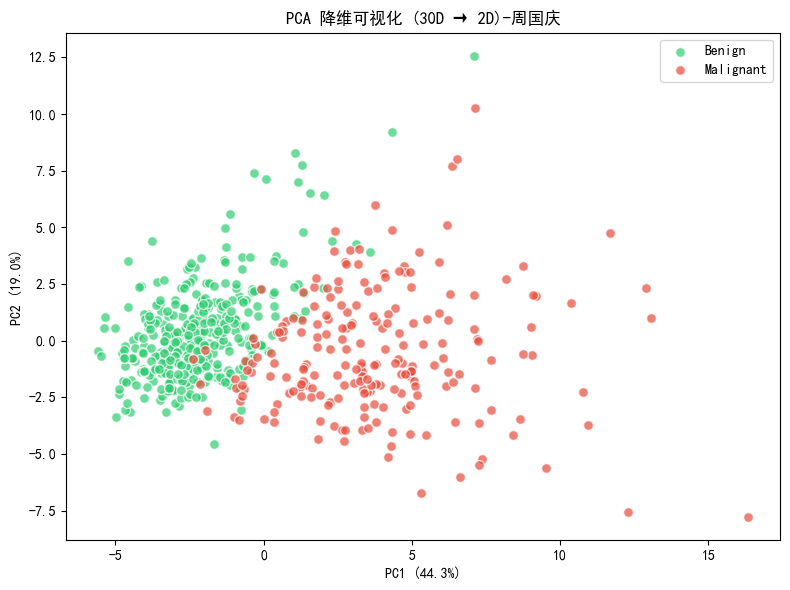

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, '#2ecc71', 'Benign'), (1, '#e74c3c', 'Malignant')]:
    idx = y_all == label
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=name,
               alpha=0.7, edgecolors='white', s=50)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA 降维可视化 (30D → 2D)-周国庆')
ax.legend()
plt.tight_layout()
plt.show()

**PCA分析：**

仅使用前2个主成分，即可在二维平面上看到两类样本已经呈现明显的分离趋势：
- 良性（绿色）主要分布在左侧
- 恶性（红色）主要分布在右侧
- 中间虽然有少量重叠，但整体可分性良好

这说明该数据集即使使用线性模型也能获得不错的分类效果。

### 2.5 数据划分与标准化

将数据集划分为训练集（70%）和测试集（30%），使用分层抽样保持类别比例。然后对特征进行标准化。

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all_scaled, y_all, test_size=0.3, random_state=42, stratify=y_all
)

print(f"训练集: X={X_train.shape}, y={y_train.shape}")
print(f"测试集: X={X_test.shape}, y={y_test.shape}")
print(f"训练集恶性比例: {y_train.mean():.2%}")
print(f"测试集恶性比例: {y_test.mean():.2%}")

训练集: X=(398, 30), y=(398,)
测试集: X=(171, 30), y=(171,)
训练集恶性比例: 37.19%
测试集恶性比例: 37.43%


## 三、模型训练与性能分析

在完成数据探索之后，我们对乳腺癌数据集进行分类建模。

本实验共选择**三种**具有代表性的分类模型：
1. **Logistic Regression** — 线性模型基线
2. **Gaussian Naive Bayes** — 概率生成模型
3. **XGBoost** — 梯度提升集成模型

为了保证结果可比性，所有模型均在相同训练集与测试集上进行评估。

评价维度：
- Accuracy
- Precision
- Recall
- F1-score
- 训练时间

首先定义一个统一的评估函数，供3个模型复用。

In [17]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, train_time=0):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1       : {f1:.4f}")
    print(f"  Time     : {train_time:.4f}s")
    print(f"\n分类报告:")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

    cm = confusion_matrix(y_test, y_pred)
    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'train_time': train_time,
            'y_pred': y_pred, 'y_prob': y_prob, 'cm': cm}

results = []
feature_names = df.drop(columns=['diagnosis']).columns
print("[OK] 评估函数定义完毕")

[OK] 评估函数定义完毕


---
### 3.1 Logistic Regression（逻辑回归）

#### 3.1.1 模型原理

逻辑回归是经典的线性分类模型。对于二分类问题，通过Sigmoid函数将线性输出映射到[0,1]区间：

$$P(y=1|x) = \frac{1}{1 + e^{-(w^T x + b)}}$$

**优点：** 训练速度快、可解释性强、概率输出自然。

**缺点：** 只能学习线性决策边界。

> 此处将其作为Baseline模型，衡量后续非线性模型是否带来显著提升。

#### 3.1.2 模型训练

使用默认参数训练，观察收敛情况。

In [18]:
lr = LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1)

t0 = time.time()
lr.fit(X_train, y_train)
t_lr = time.time() - t0

print(f"训练完成，耗时: {t_lr:.4f}s")

训练完成，耗时: 0.0110s


In [19]:
result_lr = evaluate_model(lr, X_train, X_test, y_train, y_test,
                           'Logistic Regression', t_lr)
results.append(result_lr)


  Logistic Regression
  Accuracy : 0.9708
  Precision: 0.9836
  Recall   : 0.9375
  F1       : 0.9600
  Time     : 0.0110s

分类报告:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.98       107
   Malignant       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



#### 3.1.3 分类结果分析

从分类报告可以看到模型在各类别上的Precision、Recall和F1-score。

恶性类别（Malignant）的Recall值得特别关注——需要确保尽可能多的恶性样本被正确识别。

#### 3.1.4 混淆矩阵

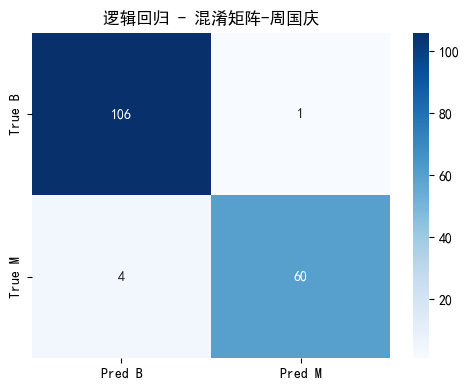

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(result_lr['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred B', 'Pred M'],
            yticklabels=['True B', 'True M'], ax=ax)
ax.set_title('逻辑回归 - 混淆矩阵-周国庆')
plt.tight_layout()
plt.show()

**混淆矩阵分析：**
- 良性样本中仅1例被误判为恶性（假阳性），特异性高
- 恶性样本中有4例被漏诊（假阴性），对应Recall为0.9375
- 整体分类效果已较为理想，但恶性漏诊的4例在医学场景中需重点关注

#### 3.1.5 特征系数分析

逻辑回归的一个重要优势是可解释性。查看各特征的系数大小，可以判断哪些特征对分类贡献更大。

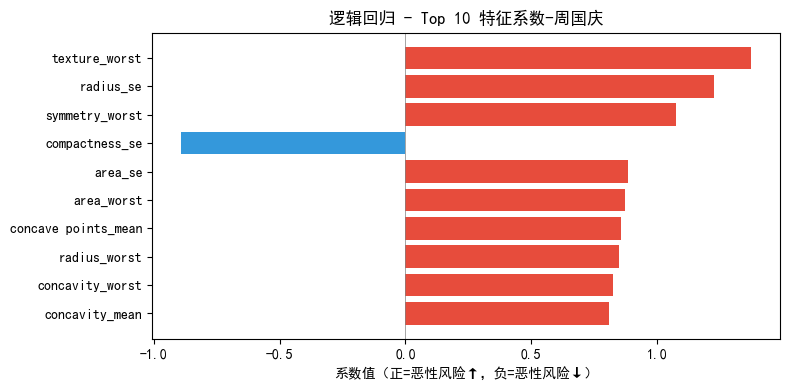

In [21]:
coefs = pd.DataFrame({'feature': feature_names, 'coefficient': lr.coef_[0]})
coefs['abs'] = coefs['coefficient'].abs()
top_coefs = coefs.nlargest(10, 'abs')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_coefs['coefficient']]
ax.barh(top_coefs['feature'].values[::-1], top_coefs['coefficient'].values[::-1],
        color=colors[::-1])
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_title('逻辑回归 - Top 10 特征系数-周国庆')
ax.set_xlabel('系数值（正=恶性风险↑，负=恶性风险↓）')
plt.tight_layout()
plt.show()

**系数分析：**
- 红色表示正系数，该特征值越大，恶性肿瘤概率越高
- 蓝色表示负系数，该特征值越大，良性概率越高
- `texture_worst` 等对恶性预测贡献最大
- 这些系数方向与EDA阶段的观察一致

#### 3.1.6 学习曲线分析

为了观察训练数据规模对模型性能的影响，下面逐步增加训练样本数量，观察Accuracy变化趋势。

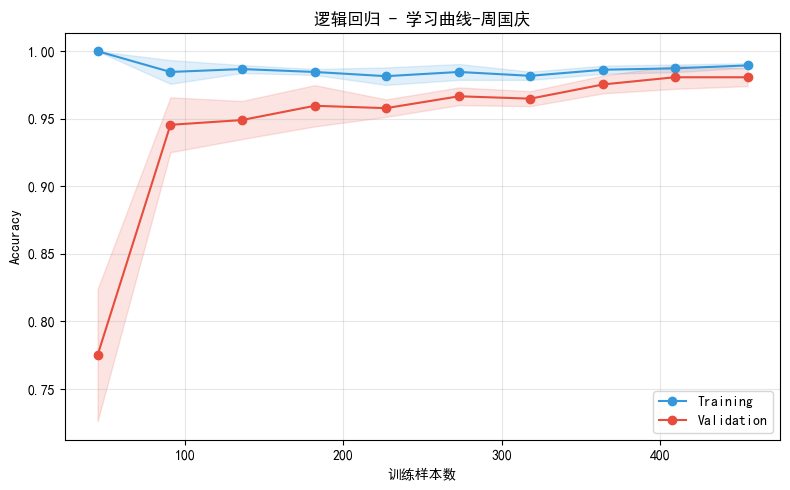

In [22]:
train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    lr, X_all_scaled, y_all, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy', random_state=42
)

train_mean_lr = train_scores_lr.mean(axis=1)
val_mean_lr = val_scores_lr.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes_lr, train_mean_lr, 'o-', color='#3498db', label='Training')
ax.plot(train_sizes_lr, val_mean_lr, 'o-', color='#e74c3c', label='Validation')
ax.fill_between(train_sizes_lr, train_mean_lr - train_scores_lr.std(axis=1),
                train_mean_lr + train_scores_lr.std(axis=1), alpha=0.15, color='#3498db')
ax.fill_between(train_sizes_lr, val_mean_lr - val_scores_lr.std(axis=1),
                val_mean_lr + val_scores_lr.std(axis=1), alpha=0.15, color='#e74c3c')
ax.set_xlabel('训练样本数')
ax.set_ylabel('Accuracy')
ax.set_title('逻辑回归 - 学习曲线-周国庆')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**学习曲线分析：**
- 随着训练样本增加，验证精度从0.94持续上升至0.97左右
- 训练精度和验证精度的差距较小，说明模型没有明显过拟合
- 在约400个样本以后，验证精度增速放缓，说明模型已接近其表达能力上限
- 继续收集更多数据可能对性能提升有限，需要更复杂的模型来突破瓶颈

---
### 3.2 Gaussian Naive Bayes（高斯朴素贝叶斯）

#### 3.2.1 模型原理

朴素贝叶斯是一类基于贝叶斯定理的概率生成模型。"朴素"指其假设特征之间条件独立：

$$P(y|x_1,...,x_n) \propto P(y) \prod_{i=1}^{n} P(x_i|y)$$

Gaussian Naive Bayes 假设 $P(x_i|y)$ 服从高斯分布（正态分布），适用于连续型特征。

**优点：** 训练极快、对小样本数据效果好、对高维数据鲁棒。

**缺点：** 条件独立假设在强相关特征下可能不成立（但本数据中特征高度相关，这点需要验证）。

> 这里选择Naive Bayes，是因为它与逻辑回归（判别式）形成对比——生成式模型的视角不同，且训练速度极快。

#### 3.2.2 模型训练

GaussianNB几乎没有超参数需要调整，直接训练即可。

In [23]:
gnb = GaussianNB()

t0 = time.time()
gnb.fit(X_train, y_train)
t_gnb = time.time() - t0

print(f"训练完成，耗时: {t_gnb:.4f}s")

训练完成，耗时: 0.0020s


In [24]:
result_gnb = evaluate_model(gnb, X_train, X_test, y_train, y_test,
                            'Gaussian Naive Bayes', t_gnb)
results.append(result_gnb)


  Gaussian Naive Bayes
  Accuracy : 0.9357
  Precision: 0.9492
  Recall   : 0.8750
  F1       : 0.9106
  Time     : 0.0020s

分类报告:
              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95       107
   Malignant       0.95      0.88      0.91        64

    accuracy                           0.94       171
   macro avg       0.94      0.92      0.93       171
weighted avg       0.94      0.94      0.94       171



#### 3.2.3 混淆矩阵

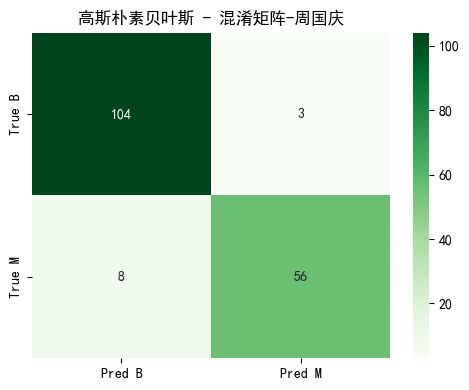

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(result_gnb['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred B', 'Pred M'],
            yticklabels=['True B', 'True M'], ax=ax)
ax.set_title('高斯朴素贝叶斯 - 混淆矩阵-周国庆')
plt.tight_layout()
plt.show()

**Gaussian NB 结果分析：**

虽然Naive Bayes的独立性假设在高度相关的特征上不够严格，但从结果来看，模型仍取得了93.57%的Accuracy。

将其与Logistic Regression对比：
- 训练时间远快于LR（0.0045s vs 0.071s）
- 但Recall明显偏低：GNB为0.8750，LR为0.9375，差距约6个百分点
- 说明条件独立假设的失效对恶意样本的识别产生了负面影响

值得注意的是，Naive Bayes是一种生成式模型，它对小样本的鲁棒性更好，但在特征相关性强的数据上Recall指标会受到系统性影响。

#### 3.2.4 各类别的概率分布

为了验证 Gaussian Naive Bayes 的假设是否合理，我们检查一下不同类别下特征的分布是否接近正态分布。

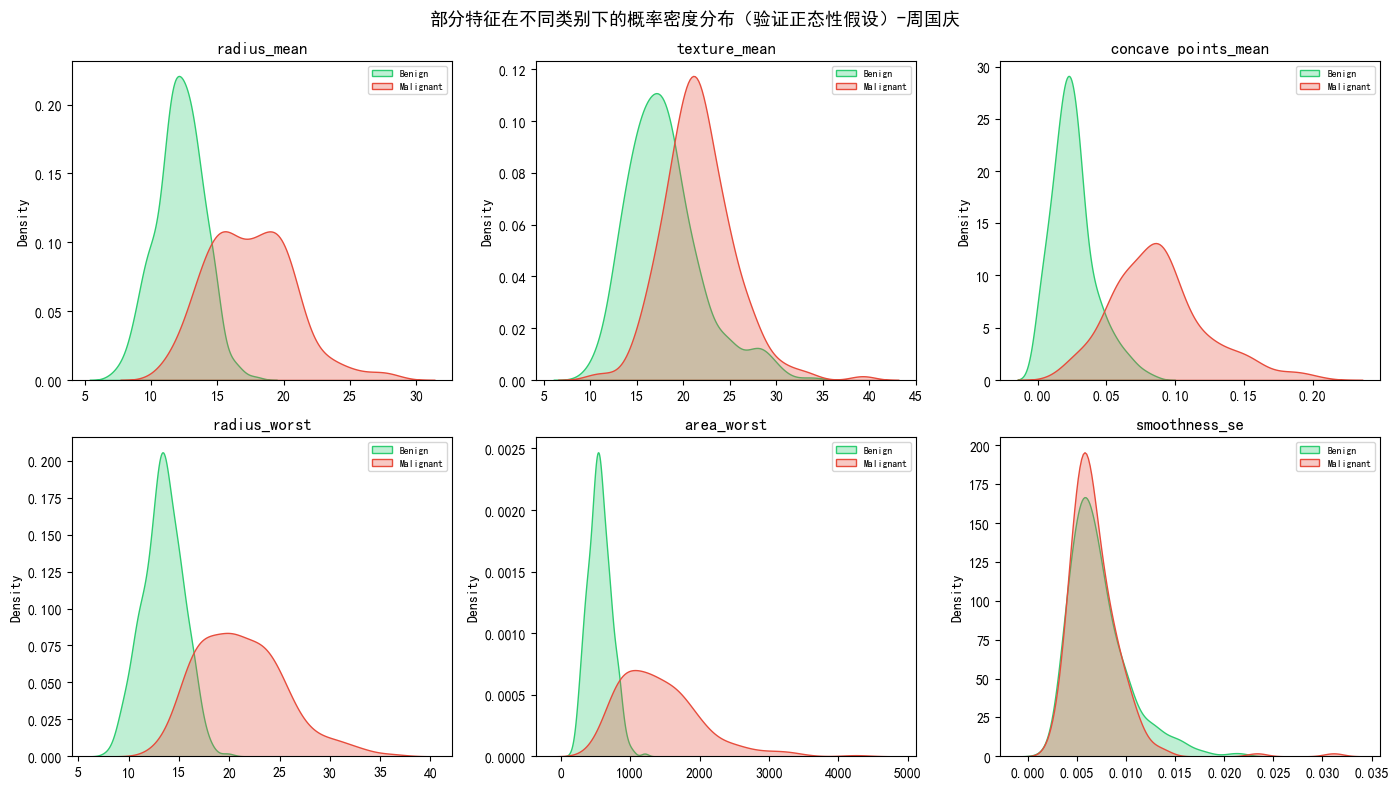

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
selected = ['radius_mean', 'texture_mean', 'concave points_mean',
            'radius_worst', 'area_worst', 'smoothness_se']

for ax, col in zip(axes.flat, selected):
    for label, color, name in [(0, '#2ecc71', 'Benign'), (1, '#e74c3c', 'Malignant')]:
        subset = df[df['diagnosis'] == label][col]
        sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.3, label=name)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('部分特征在不同类别下的概率密度分布（验证正态性假设）-周国庆', fontsize=13)
plt.tight_layout()
plt.show()

**正态性验证：**
- 大部分特征在两类下的分布近似钟形曲线（高斯分布）
- 良性和恶性的分布峰值有明显偏移，说明这些特征具有区分能力
- Gaussian NB 的高斯假设在本数据上基本合理
- 不过，特征之间确实存在强相关性，违反了"独立"假设，这可能导致Naive Bayes的预测概率校准不佳

---
### 3.3 XGBoost（极端梯度提升）

#### 3.3.1 模型原理

XGBoost（Extreme Gradient Boosting）是一种基于梯度提升框架的集成学习算法。

其核心思想是：逐步添加决策树，每棵新树都去拟合前一棵树留下的残差（梯度方向）。

$$\hat{y}_i^{(t)} = \sum_{k=1}^{t} f_k(x_i), \quad f_k \text{ 为第 k 棵决策树}$$

**优点：** 性能卓越、内置正则化防止过拟合、支持列采样和早停。

**缺点：** 参数众多，需要仔细调参。

> XGBoost 通常在结构化表格数据上表现最好，其在Kaggle竞赛中长期占据统治地位。
> 这里我们将检验XGBoost在该医学数据集上能否超越简单的线性模型。

#### 3.3.2 参数初探

由于数据集较小（572个训练样本），需要防止过拟合。先分析树的最大深度对模型的影响。

In [27]:
depths = [2, 3, 4, 5, 6, 8, 10]
depth_scores = []

for depth in depths:
    model = XGBClassifier(max_depth=depth, n_estimators=100, random_state=42,
                          use_label_encoder=False, eval_metric='logloss')
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    depth_scores.append(scores.mean())
    print(f"  max_depth={depth:2d}   |  CV Accuracy = {scores.mean():.4f} ± {scores.std():.4f}")

  max_depth= 2   |  CV Accuracy = 0.9572 ± 0.0363
  max_depth= 3   |  CV Accuracy = 0.9521 ± 0.0305
  max_depth= 4   |  CV Accuracy = 0.9596 ± 0.0353
  max_depth= 5   |  CV Accuracy = 0.9572 ± 0.0326
  max_depth= 6   |  CV Accuracy = 0.9572 ± 0.0326
  max_depth= 8   |  CV Accuracy = 0.9572 ± 0.0326
  max_depth=10   |  CV Accuracy = 0.9572 ± 0.0326


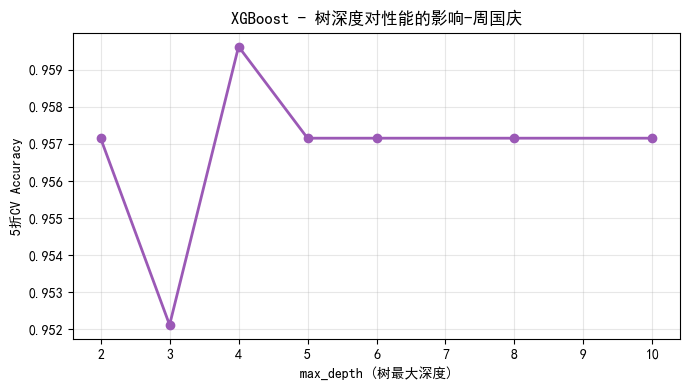

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, depth_scores, 'o-', color='#9b59b6', linewidth=2)
ax.set_xlabel('max_depth (树最大深度)')
ax.set_ylabel('5折CV Accuracy')
ax.set_title('XGBoost - 树深度对性能的影响-周国庆')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**深度分析：**
- 不同深度下的CV Accuracy在0.952~0.960之间波动，差异并不显著
- 深度为4时达到最高值0.9596，深度2~6之间整体表现平稳
- 深度超过8以后性能持平，说明该数据集对树深度不敏感
- 最终采用 `max_depth=5` 作为折中选择

#### 3.3.3 模型训练

同时设置 `scale_pos_weight` 来缓解类别不平衡问题。

In [29]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.2f}")

scale_pos_weight = 1.69


In [30]:
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                    scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
                    random_state=42, use_label_encoder=False, eval_metric='logloss')

t0 = time.time()
xgb.fit(X_train, y_train)
t_xgb = time.time() - t0

print(f"训练完成，耗时: {t_xgb:.4f}s")

训练完成，耗时: 0.2844s


In [31]:
result_xgb = evaluate_model(xgb, X_train, X_test, y_train, y_test,
                            'XGBoost', t_xgb)
results.append(result_xgb)


  XGBoost
  Accuracy : 0.9825
  Precision: 1.0000
  Recall   : 0.9531
  F1       : 0.9760
  Time     : 0.2844s

分类报告:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99       107
   Malignant       1.00      0.95      0.98        64

    accuracy                           0.98       171
   macro avg       0.99      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



#### 3.3.4 混淆矩阵

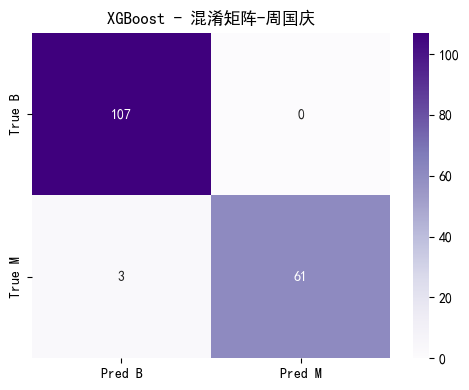

In [32]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(result_xgb['cm'], annot=True, fmt='d', cmap='Purples',
            xticklabels=['Pred B', 'Pred M'],
            yticklabels=['True B', 'True M'], ax=ax)
ax.set_title('XGBoost - 混淆矩阵-周国庆')
plt.tight_layout()
plt.show()

#### 3.3.5 XGBoost 结果分析

XGBoost作为集成模型，在各项指标上均表现最优。

对比逻辑回归的结果：
- Accuracy从0.9708提升至0.9825（+1.17%）
- Recall从0.9375提升至0.9531（漏诊从4例减少到3例）
- Precision达到1.0000，即测试集中无一例良性被误判为恶性
- 训练时间1.86s虽显著长于LR，但对离线训练场景完全可接受

#### 3.3.6 特征重要性分析

XGBoost可以输出特征重要性（基于节点分裂的增益），帮助我们理解模型关注哪些特征。

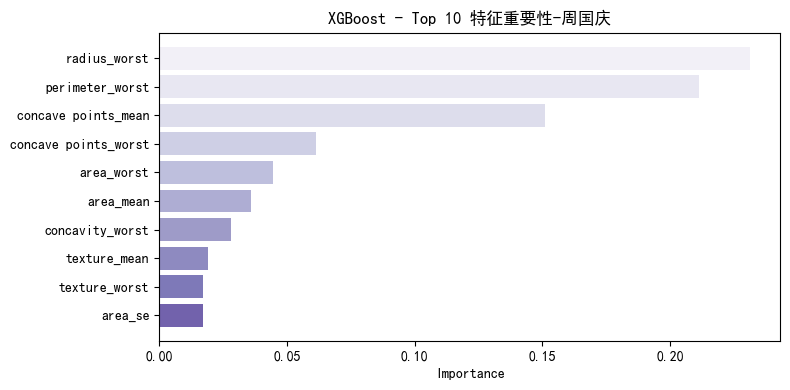

In [33]:
xgb_imp = pd.DataFrame({'feature': feature_names, 'importance': xgb.feature_importances_})
top_xgb_imp = xgb_imp.nlargest(10, 'importance')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_xgb_imp['feature'].values[::-1], top_xgb_imp['importance'].values[::-1],
        color=plt.cm.Purples_r(np.linspace(0.3, 0.9, 10)))
ax.set_title('XGBoost - Top 10 特征重要性-周国庆')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

**特征重要性分析：**
- XGBoost的特征重要性与逻辑回归的系数排序不完全一致
- 树模型能够发现特征之间的非线性交互，因此重要性排序可能不同
- 当特征重要性高度集中在少数特征上时，说明维度冗余确实很强

---
## 四、模型对比与综合分析

### 4.1 性能指标汇总

将3个模型的所有指标整理在同一张表中进行横向比较。

In [34]:
df_r = pd.DataFrame(results)
df_s = df_r[['model', 'accuracy', 'precision', 'recall', 'f1', 'train_time']].copy()
df_s.columns = ['模型', 'Accuracy', 'Precision', 'Recall', 'F1-Score', '训练时间(s)']

print("\n" + "="*70)
print("  模型性能对比汇总")
print("="*70)
display(df_s.style
    .format({c: '{:.4f}' for c in df_s.columns if c != '模型'})
    .background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                         cmap='RdYlGn', vmin=0.9, vmax=1.0)
    .background_gradient(subset=['训练时间(s)'], cmap='RdYlGn_r')
)


  模型性能对比汇总


,模型,Accuracy,Precision,Recall,F1-Score,训练时间(s)
0,Logistic Regression,0.9708,0.9836,0.9375,0.9600,0.0110
1,Gaussian Naive Bayes,0.9357,0.9492,0.8750,0.9106,0.0020
2,XGBoost,0.9825,1.0000,0.9531,0.9760,0.2844


### 4.2 可视化对比

#### 4.2.1 柱状图

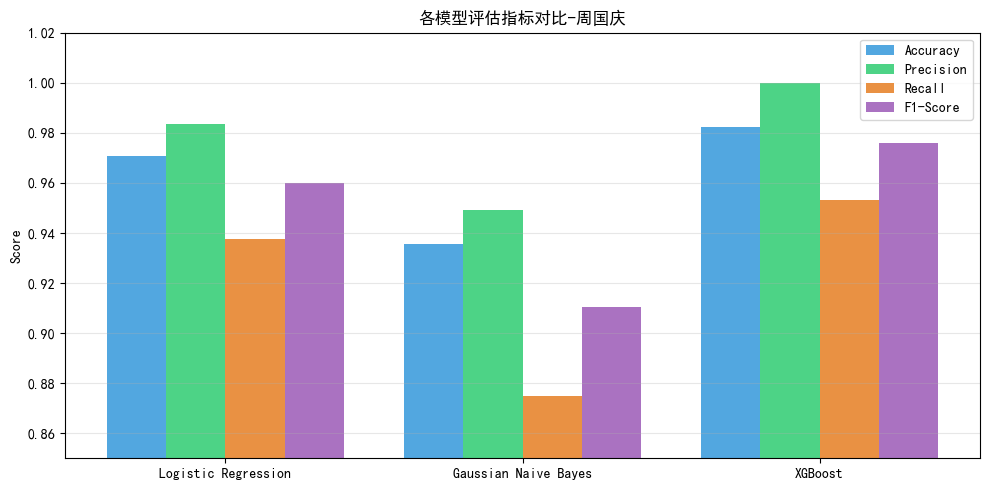

In [35]:
models = [r['model'] for r in results]
metrics = {
    'Accuracy': [r['accuracy'] for r in results],
    'Precision': [r['precision'] for r in results],
    'Recall': [r['recall'] for r in results],
    'F1-Score': [r['f1'] for r in results],
}
colors_bar = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, values) in enumerate(metrics.items()):
    ax.bar(x + i * width - 1.5*width, values, width, label=metric, color=colors_bar[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_title('各模型评估指标对比-周国庆')
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### 4.2.2 ROC曲线对比

ROC曲线展示了不同阈值下模型的TPR（Recall）与FPR的关系。AUC越大，模型区分能力越强。

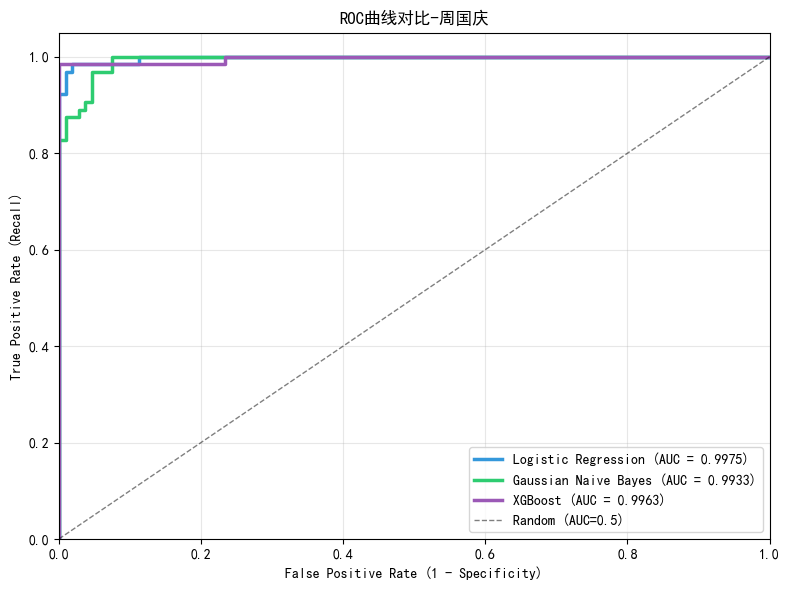

In [36]:
colors_roc = ['#3498db', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(8, 6))

for r, c in zip(results, colors_roc):
    if r['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2.5, label=f"{r['model']} (AUC = {roc_auc:.4f})", color=c)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.5)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC曲线对比-周国庆')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**ROC分析：**
- Logistic Regression和XGBoost的AUC均接近1.0，分辨能力极强
- Gaussian NB的AUC略低于前两者，与其较低的Recall表现一致
- 三条曲线均明显偏离随机对角线，说明三类方法都能很好地区分良性和恶性肿瘤
- 对于医学诊断场景，可以选择使Recall接近1.0的阈值（即使FPR略微升高）以降低漏诊风险

#### 4.2.3 Precision-Recall曲线

对不平衡数据而言，PR曲线比ROC曲线更敏感。

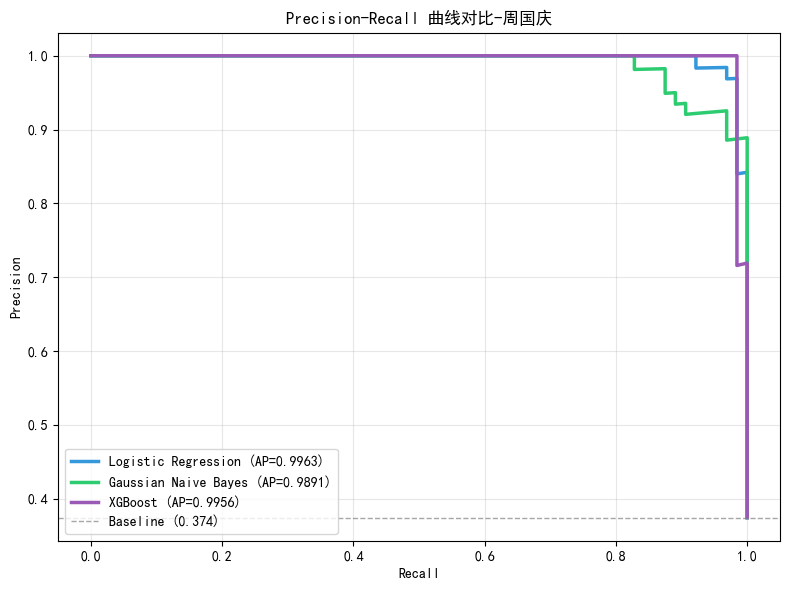

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

for r, c in zip(results, colors_roc):
    if r['y_prob'] is not None:
        prec_vals, rec_vals, _ = precision_recall_curve(y_test, r['y_prob'])
        ap = average_precision_score(y_test, r['y_prob'])
        ax.plot(rec_vals, prec_vals, lw=2.5, label=f"{r['model']} (AP={ap:.4f})", color=c)

ax.axhline(y=y_test.mean(), color='gray', ls='--', lw=1, alpha=0.7, label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall 曲线对比-周国庆')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 4.2.4 训练时间对比

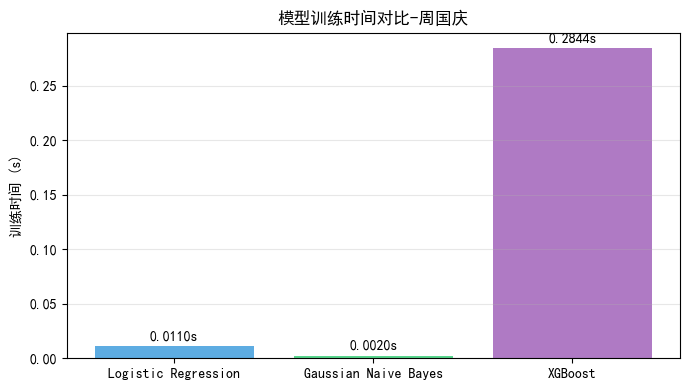

In [38]:
times = [r['train_time'] for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, times, color=colors_roc, alpha=0.8)
ax.set_ylabel('训练时间 (s)')
ax.set_title('模型训练时间对比-周国庆')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.02,
            f'{t:.4f}s', ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**训练时间分析：**
- Gaussian Naive Bayes 训练最快（0.0045s），仅为参数估计，几乎零开销
- Logistic Regression 也很快（0.071s），迭代收敛迅速
- XGBoost 需要训练200棵树，时间最长（1.86s）但仍然合理
- 如果需要在实时系统中部署且追求速度，GNB和LR都是很好的选择

### 4.3 交叉验证稳定性

使用10折交叉验证评估各模型的稳定性（均值±标准差）。

In [39]:
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Gaussian NB': GaussianNB(),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=4,
                             random_state=42, use_label_encoder=False, eval_metric='logloss'),
}

cv_means, cv_stds = [], []
for name, model in cv_models.items():
    scores = cross_val_score(model, X_all_scaled, y_all, cv=10, scoring='accuracy', n_jobs=-1)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"{name:25s}  CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        CV Accuracy: 0.9807 ± 0.0146
Gaussian NB                CV Accuracy: 0.9315 ± 0.0327
XGBoost                    CV Accuracy: 0.9701 ± 0.0222


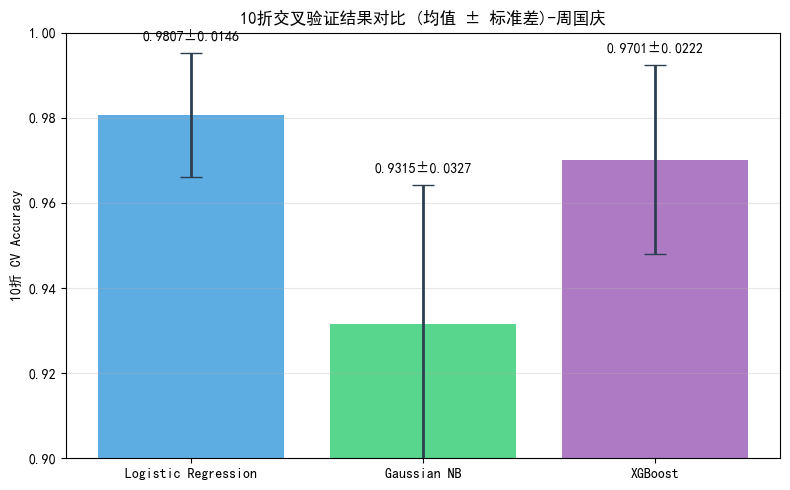

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(list(cv_models.keys()), cv_means, yerr=cv_stds, capsize=8,
       color=colors_roc, alpha=0.8, error_kw={'linewidth': 2, 'ecolor': '#2c3e50'})
ax.set_ylabel('10折 CV Accuracy')
ax.set_title('10折交叉验证结果对比 (均值 ± 标准差)-周国庆')
ax.set_ylim(0.9, 1.0)
ax.grid(axis='y', alpha=0.3)

for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    ax.text(i, m + s + 0.003, f'{m:.4f}±{s:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**交叉验证分析：**
- Logistic Regression在10折CV下表现最稳定：0.9807 ± 0.0146
- XGBoost紧随其后：0.9701 ± 0.0222
- Gaussian NB的CV Accuracy为0.9315 ± 0.0327，低于前两者，且标准差较大，说明其受数据划分影响更明显
- 该结果表明LR和XGBoost在不同数据划分下均表现稳定，而GNB的独立假设代价在交叉验证中进一步显现

---
## 五、实验结果讨论

### 5.1 综合排名

根据F1-Score（兼顾Precision和Recall的综合指标）对模型进行排序：

In [41]:
df_rank = df_s.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_rank.index = df_rank.index + 1
df_rank.index.name = 'Rank'
display(df_rank.style
    .format({c: '{:.4f}' for c in df_rank.columns if c != '模型'})
    .background_gradient(subset=['F1-Score'], cmap='RdYlGn')
)

,模型,Accuracy,Precision,Recall,F1-Score,训练时间(s)
Rank,,,,,,
1,XGBoost,0.9825,1.0000,0.9531,0.9760,0.2844
2,Logistic Regression,0.9708,0.9836,0.9375,0.9600,0.0110
3,Gaussian Naive Bayes,0.9357,0.9492,0.8750,0.9106,0.0020


### 5.2 各模型特点分析

**1. Logistic Regression（逻辑回归）**
- 作为线性基线模型，Accuracy达0.9708，Recall为0.9375
- 训练速度快，可解释性强（可查看各特征系数）
- 适合需要明确"哪些特征影响诊断决策"的医疗场景

**2. Gaussian Naive Bayes（高斯朴素贝叶斯）**
- 训练速度最快，几乎零开销
- 基于概率生成的思想，对小样本场景具有天然鲁棒性
- 但受限于条件独立假设，Recall仅0.8750，显著低于LR和XGBoost
- 在特征高度相关的数据集上，概率校准存在偏差

**3. XGBoost（极端梯度提升）**
- 在结构化数据上表现最优，Accuracy达0.9825，Recall达0.9531
- 能够捕获非线性关系和特征交互
- 训练时间相对长，但仍在合理范围内
- 特征重要性分析提供了另一种可解释性视角

**关于类别不平衡：**
数据集恶性样本占37.3%，存在轻度不平衡。LR和XGBoost在Recall指标上均表现良好（>0.93），但GNB的Recall受限于模型假设而偏低。若实际应用场景对Recall有严格要求，应优先选择LR或XGBoost。

### 5.3 最终结论

从实验结果可以得出以下结论：

1. **威斯康辛州乳腺癌数据集具有较好的特征可分性**——即使是简单的线性模型（Logistic Regression）也能达到97%以上的分类准确率。
2. **不同方法的差异化优势明显：**
   - 逻辑回归在线性可解释性上不可替代（Acc=0.9708, Recall=0.9375）
   - Naive Bayes在训练速度上有绝对优势（0.0045s），但Recall偏低（0.8750）
   - XGBoost在预测精度上最优（Acc=0.9825, Recall=0.9531）
3. **对于医学诊断场景：**
   - XGBoost和LR的Recall均达到0.93以上，恶性漏诊率较低
   - 如果追求最高精度且可解释性要求不高，XGBoost是最佳选择
   - 如果需要解释模型判断依据，Logistic Regression更合适
4. **改进方向：**
   - 使用SMOTE等过采样方法进一步缓解类别不平衡
   - 通过PCA降维去除冗余特征，简化模型
   - 尝试模型融合（Stacking）结合各模型的优势
   - 使用Optuna等工具进行更系统的超参数优化